### Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, SparsePCA
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import silhouette_score

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('HR_data_2.csv')
print("Raw shape:", df.shape)

df_clean = df.dropna().reset_index(drop=True)
print("Clean shape:", df_clean.shape)

Raw shape: (312, 71)
Clean shape: (307, 71)


### Feature Split

Separate the attributes that you never want accidentally entering PCA (Meta Columns and Admin Columns)

In [3]:
biosignal_cols = [c for c in df_clean.columns
                  if c.startswith(('HR_TD_', 'TEMP_TD_', 'EDA_TD_'))]
meta_cols = ['Phase', 'Individual', 'Cohort', 'Round', 'Puzzler', 'Team_ID']

X_raw = df_clean[biosignal_cols].astype(float).copy()
meta  = df_clean[meta_cols].copy()

### Handle Skewness

Biosignal features are skewed (as seen in data processing part). So we utilize Yeo-Johnson that both normalises skew and accepts negative values with standardisation, so every column has mean 0, variance 1 — a requirement for PCA to treat features equally.

Fitted independently per individual due to massive inter-subject variabilit and individual baselines.

In [4]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_scaled = X_raw.copy()
for subj in meta['Individual'].unique():
    idx = meta['Individual'] == subj
    X_scaled.loc[idx, biosignal_cols] = pt.fit_transform(X_raw.loc[idx])

### Fit PCA

In [5]:
pca = PCA(random_state=SEED).fit(X_scaled)
scores = pca.transform(X_scaled)
evr = pca.explained_variance_ratio_

### Scree & Cumulative variance Plot with Parallel Analysis

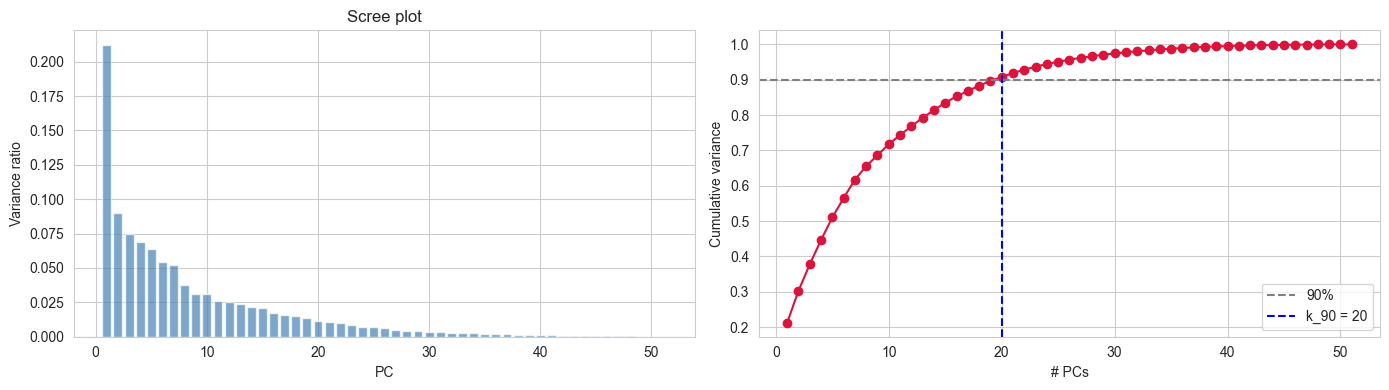

k from 90% variance      : 20
k from parallel analysis : 10


In [6]:
# Scree + cumulative
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(1, len(evr)+1), evr, color='steelblue', alpha=0.7)
axes[0].set(xlabel='PC', ylabel='Variance ratio', title='Scree plot')

cum = np.cumsum(evr)
k_90 = int(np.searchsorted(cum, 0.90) + 1)
axes[1].plot(range(1, len(cum)+1), cum, 'o-', color='crimson')
axes[1].axhline(0.90, ls='--', color='gray', label='90%')
axes[1].axvline(k_90, ls='--', color='blue', label=f'k_90 = {k_90}')
axes[1].set(xlabel='# PCs', ylabel='Cumulative variance')
axes[1].legend()
plt.tight_layout(); plt.show()

# Parallel analysis
rng = np.random.default_rng(SEED)
null_eigs = []
for _ in range(200):
    X_perm = np.column_stack([rng.permutation(X_scaled.iloc[:, j].values)
                              for j in range(X_scaled.shape[1])])
    null_eigs.append(PCA().fit(X_perm).explained_variance_)
null_q95 = np.quantile(np.vstack(null_eigs), 0.95, axis=0)
k_pa = int((pca.explained_variance_ > null_q95).sum())

print(f"k from 90% variance      : {k_90}")
print(f"k from parallel analysis : {k_pa}")
k = k_pa

### PC1–PC2 scatter (Phase, Individual and Cohort)

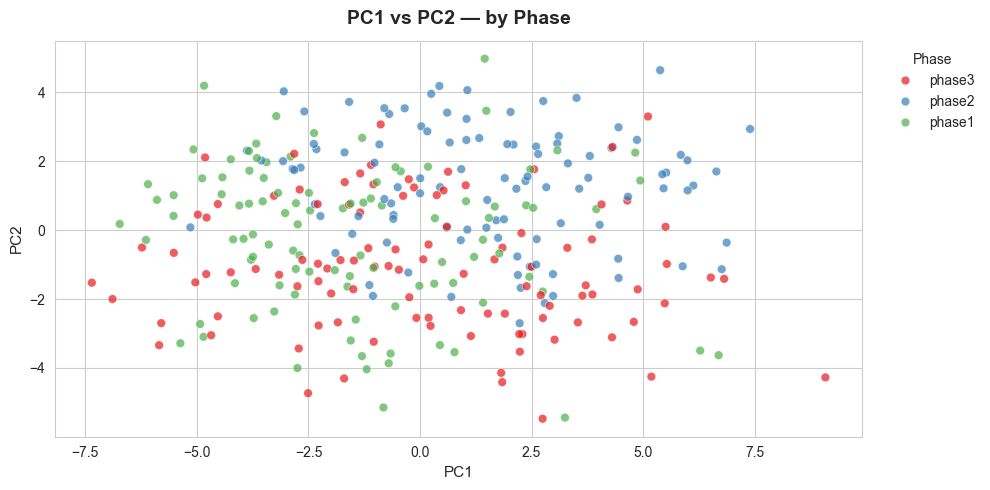

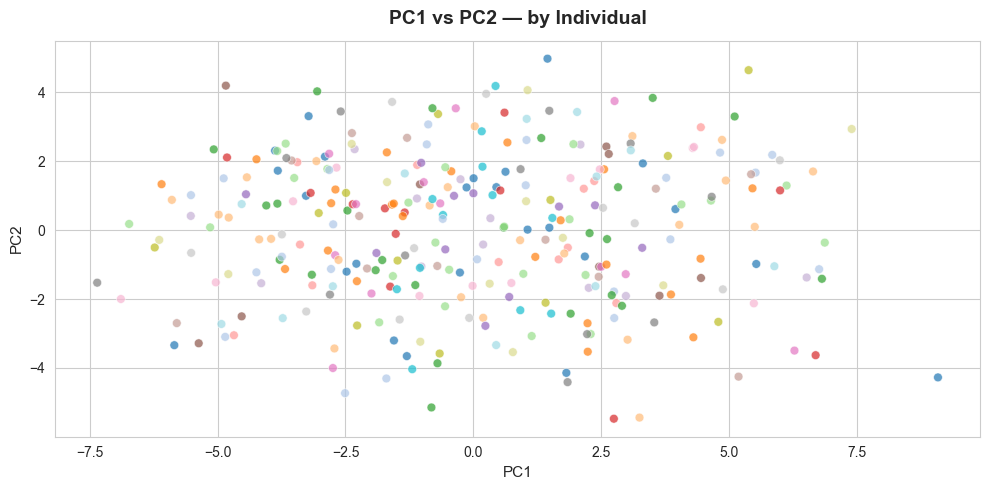

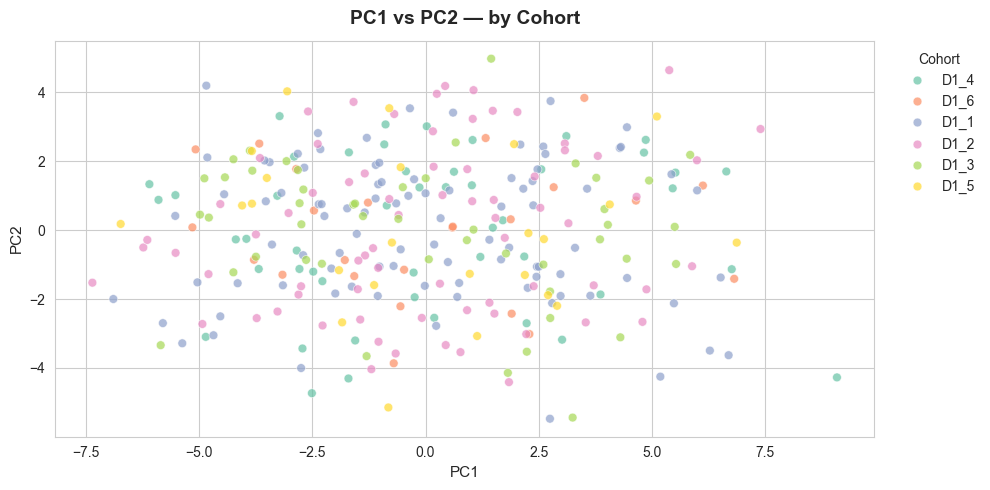

In [7]:
for col, pal in zip(['Phase', 'Individual', 'Cohort'],
                    ['Set1', 'tab20', 'Set2']):
    
    show_leg = col != 'Individual'
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=meta[col],
                    palette=pal, s=40, alpha=0.7, edgecolor='white', linewidth=0.5, ax=ax,
                    legend='full' if show_leg else False)
    
    ax.set_title(f'PC1 vs PC2 — by {col}', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)

    if show_leg:
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title=col, frameon=False)

    plt.tight_layout()
    plt.show()

When looking at Phase wise, PC1 does not visibly separate phases.  This is the "weak signal" expected with wearable biosignals. Colouring the same points by Individual (middle) and Cohort (right) shows uniform mixing — the per-subject preprocessing has successfully removed individual and cohort-level confounds from the representation

In [8]:
sil_phase_2D = silhouette_score(scores[:, :2], meta['Phase'])
sil_indiv_2D = silhouette_score(scores[:, :2], meta['Individual'])
sil_phase_kD = silhouette_score(scores[:, :k], meta['Phase'])
sil_indiv_kD = silhouette_score(scores[:, :k], meta['Individual'])

print(f"Silhouette  Phase  2D: {sil_phase_2D:+.3f}   {k}D: {sil_phase_kD:+.3f}")
print(f"Silhouette  Indiv  2D: {sil_indiv_2D:+.3f}   {k}D: {sil_indiv_kD:+.3f}")

Silhouette  Phase  2D: +0.021   10D: +0.018
Silhouette  Indiv  2D: -0.214   10D: -0.079


We measured how well the data clusters together (the Silhouette Score) using two different labels:

Phase Silhouette (+0.018): A positive score shows the model successfully, though weakly, separates the actual experiment phases.

Individual Silhouette (−0.079): A negative score proves the data does not group together by the person's identity

Conclusion: Because the Phase score is higher than the Individual score our per-subject scaling worked.

### PC and Phase correlation heatmap

Checking at what state the PC score goes up or down in

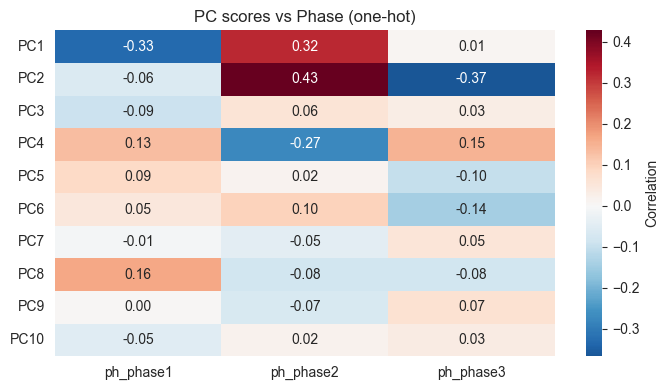


Phase-tracking summary:
  ph_phase1: PC1  (r = -0.329)
  ph_phase2: PC2  (r = +0.427)
  ph_phase3: PC2  (r = -0.366)


In [9]:
phase_oh = pd.get_dummies(meta['Phase'], prefix='ph').astype(int)

corr_mat = np.zeros((k, phase_oh.shape[1]))
for i in range(k):
    for j in range(phase_oh.shape[1]):
        corr_mat[i, j] = np.corrcoef(scores[:, i], phase_oh.values[:, j])[0, 1]

corr_df = pd.DataFrame(corr_mat,
                       index=[f'PC{i+1}' for i in range(k)],
                       columns=phase_oh.columns)

plt.figure(figsize=(7, max(4, k*0.35)))
sns.heatmap(corr_df, center=0, cmap='RdBu_r', annot=True, fmt='.2f',
            cbar_kws={'label': 'Correlation'})
plt.title('PC scores vs Phase (one-hot)')
plt.tight_layout(); plt.show()

print("\nPhase-tracking summary:")
for col in corr_df.columns:
    top_pc = corr_df[col].abs().idxmax()
    r = corr_df.loc[top_pc, col]
    print(f"  {col}: {top_pc}  (r = {r:+.3f})")

### Block contribution per PC

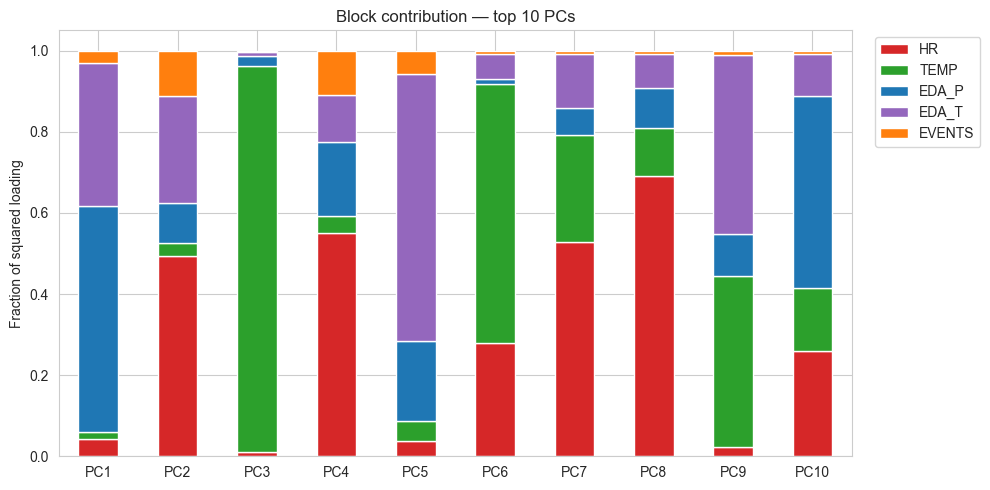

        HR  TEMP  EDA_P  EDA_T  EVENTS
PC1   0.04  0.02   0.56   0.35    0.03
PC2   0.49  0.03   0.10   0.26    0.11
PC3   0.01  0.95   0.03   0.01    0.00
PC4   0.55  0.04   0.18   0.12    0.11
PC5   0.04  0.05   0.20   0.66    0.06
PC6   0.28  0.64   0.01   0.06    0.01
PC7   0.53  0.26   0.07   0.13    0.01
PC8   0.69  0.12   0.10   0.08    0.01
PC9   0.02  0.42   0.10   0.44    0.01
PC10  0.26  0.15   0.48   0.10    0.01


In [10]:
def get_block(c):
    if c.startswith('HR_TD_'):   return 'HR'
    if c.startswith('TEMP_TD_'): return 'TEMP'
    if c in ['EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT']: return 'EVENTS'
    if c.startswith('EDA_TD_P_'): return 'EDA_P'
    if c.startswith('EDA_TD_T_'): return 'EDA_T'

blocks = ['HR', 'TEMP', 'EDA_P', 'EDA_T', 'EVENTS']
block_mask = {b: np.array([get_block(c) == b for c in biosignal_cols]) for b in blocks}

contrib = np.zeros((k, len(blocks)))
for i in range(k):
    sq = pca.components_[i]**2
    for j, b in enumerate(blocks):
        contrib[i, j] = sq[block_mask[b]].sum()
contrib_df = pd.DataFrame(contrib,
                          index=[f'PC{i+1}' for i in range(k)], columns=blocks)

contrib_df.plot(kind='bar', stacked=True, figsize=(10, 5),
                color=['#d62728','#2ca02c','#1f77b4','#9467bd','#ff7f0e'])
plt.ylabel('Fraction of squared loading')
plt.title(f'Block contribution — top {k} PCs')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

print(contrib_df.round(2))

### Leave-One-Subject-Out (LOSO) PC1 stability

In [11]:
ref = pca.components_[0]
vectors = []
for tr, _ in LeaveOneGroupOut().split(X_scaled, groups=meta['Individual']):
    pc1 = PCA(n_components=1, random_state=SEED).fit(X_scaled.iloc[tr]).components_[0]
    pc1 = pc1 * np.sign(pc1 @ ref)    
    vectors.append(pc1)

M = np.array(vectors)
cos = (M @ M.T) / np.outer(np.linalg.norm(M, axis=1), np.linalg.norm(M, axis=1))
stability = cos[np.triu_indices_from(cos, k=1)].mean()
print(f"LOSO PC1 stability (mean pairwise cosine, sign-aligned): {stability:.3f}")

LOSO PC1 stability (mean pairwise cosine, sign-aligned): 0.999


Leave-one-subject-out reanalysis of PC1 yields a mean pairwise cosine similarity of 0.999 (sign-aligned), indicating that PC1 is reproducible across held-out subjects

### Sparse PCA

Standard PCA loadings are dense — every PC is a weighted sum of all 51 features, so interpreting a PC requires reading 51 numbers with most near-zero-but-not-zero. Sparse PCA adds a penalty that kills small loadings exactly, leaving each component as a handful of named features.

In [12]:
alpha = 1.0
spca = SparsePCA(n_components=k, alpha=alpha, random_state=SEED, max_iter=1000).fit(X_scaled)

nz = np.mean(np.sum(spca.components_ != 0, axis=1))
print(f"α = {alpha}: avg non-zero loadings per PC = {nz:.1f}")

if nz > 20:
    alpha = 2.0
    spca = SparsePCA(n_components=k, alpha=alpha, random_state=SEED, max_iter=1000).fit(X_scaled)
    print(f"→ adjusted α = {alpha}: {np.mean(np.sum(spca.components_ != 0, axis=1)):.1f}")
elif nz < 3:
    alpha = 0.5
    spca = SparsePCA(n_components=k, alpha=alpha, random_state=SEED, max_iter=1000).fit(X_scaled)
    print(f"→ adjusted α = {alpha}: {np.mean(np.sum(spca.components_ != 0, axis=1)):.1f}")

α = 1.0: avg non-zero loadings per PC = 13.5


### Loading plots (PCA vs SPCA) - top 15 features

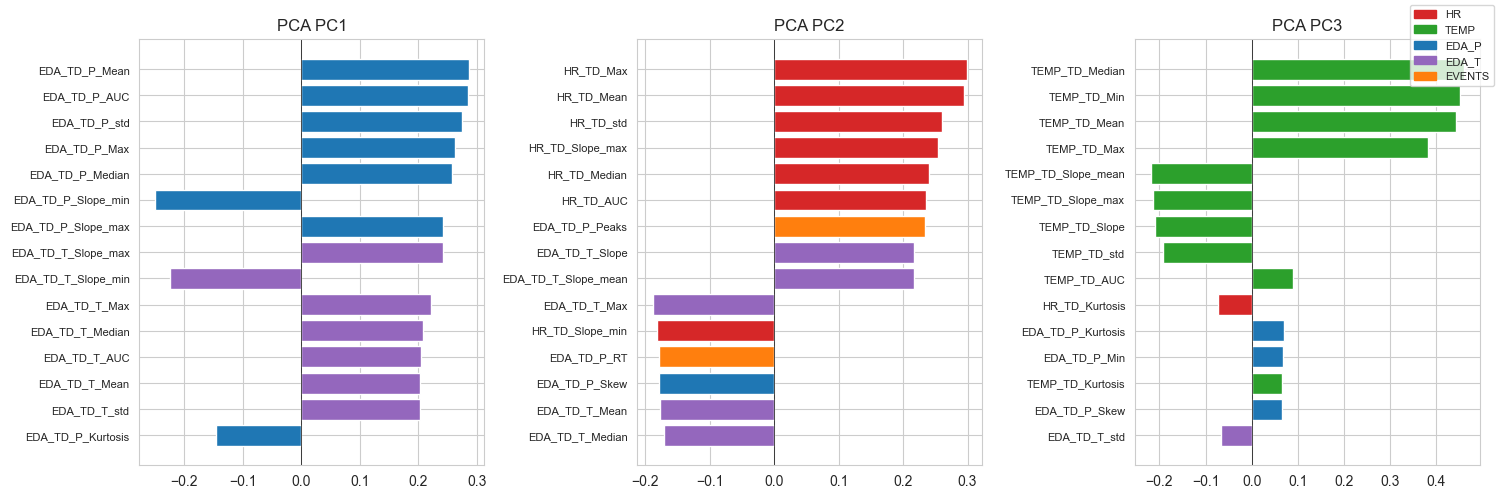

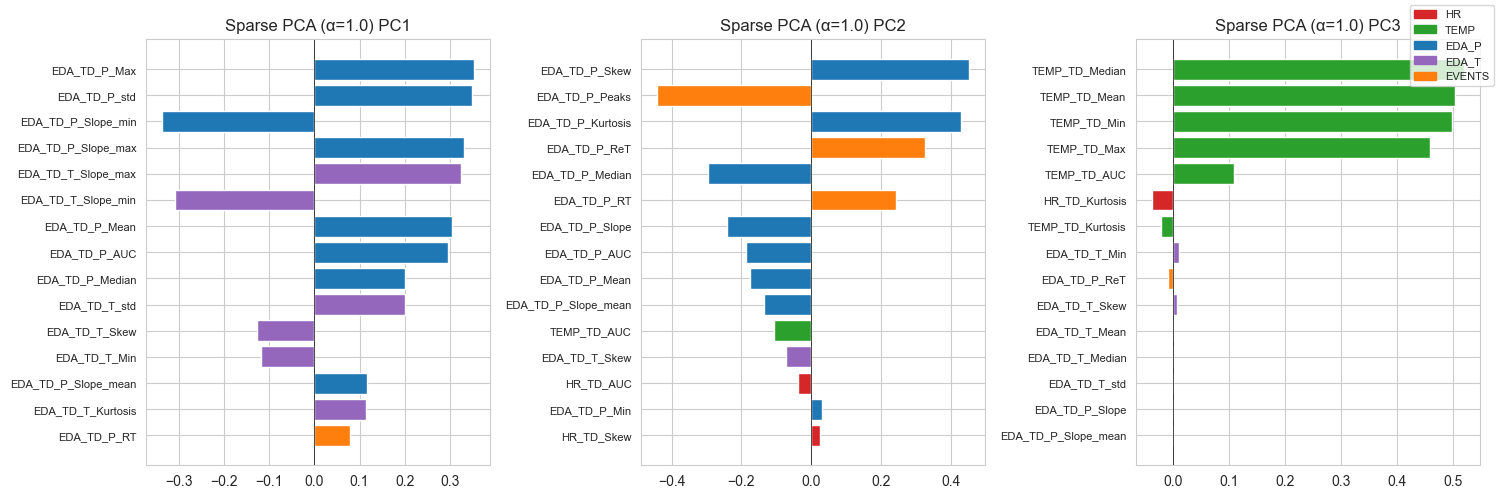

In [13]:
colors = {'HR':'#d62728','TEMP':'#2ca02c','EDA_P':'#1f77b4',
          'EDA_T':'#9467bd','EVENTS':'#ff7f0e'}

def plot_loadings(components, title, top_n=15):
    n = min(3, components.shape[0])
    fig, axes = plt.subplots(1, n, figsize=(15, 5), sharey=False)
    if n == 1: axes = [axes]
    for i, ax in enumerate(axes):
        s = pd.Series(components[i], index=biosignal_cols)
        top = s.reindex(s.abs().sort_values(ascending=False).index).head(top_n)
        bar_colors = [colors[get_block(c)] for c in top.index]
        ax.barh(range(len(top)), top.values, color=bar_colors)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(top.index, fontsize=8)
        ax.axvline(0, color='k', lw=0.5)
        ax.set_title(f'{title} PC{i+1}')
        ax.invert_yaxis()
    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color=c, label=b) for b, c in colors.items()],
               loc='upper right', fontsize=8)
    plt.tight_layout(); plt.show()

plot_loadings(pca.components_,  'PCA')
plot_loadings(spca.components_, f'Sparse PCA (α={alpha})')

### Non-zero feature lists per sparse component

In [14]:
for i in range(min(3, spca.components_.shape[0])):
    s = pd.Series(spca.components_[i], index=biosignal_cols)
    nz = s[s != 0].sort_values(key=abs, ascending=False)
    print(f"\nSparse PC{i+1}  ({len(nz)} non-zero features):")
    print(nz.round(3).to_string())


Sparse PC1  (20 non-zero features):
EDA_TD_P_Max           0.354
EDA_TD_P_std           0.348
EDA_TD_P_Slope_min    -0.338
EDA_TD_P_Slope_max     0.332
EDA_TD_T_Slope_max     0.325
EDA_TD_T_Slope_min    -0.308
EDA_TD_P_Mean          0.304
EDA_TD_P_AUC           0.297
EDA_TD_P_Median        0.201
EDA_TD_T_std           0.201
EDA_TD_T_Skew         -0.126
EDA_TD_T_Min          -0.117
EDA_TD_P_Slope_mean    0.116
EDA_TD_T_Kurtosis      0.115
EDA_TD_P_RT            0.080
EDA_TD_T_Max           0.056
HR_TD_Skew            -0.014
EDA_TD_T_Median        0.010
TEMP_TD_Skew          -0.009
HR_TD_Median           0.001

Sparse PC2  (20 non-zero features):
EDA_TD_P_Skew          0.452
EDA_TD_P_Peaks        -0.442
EDA_TD_P_Kurtosis      0.430
EDA_TD_P_ReT           0.326
EDA_TD_P_Median       -0.295
EDA_TD_P_RT            0.242
EDA_TD_P_Slope        -0.241
EDA_TD_P_AUC          -0.188
EDA_TD_P_Mean         -0.177
EDA_TD_P_Slope_mean   -0.134
TEMP_TD_AUC           -0.106
EDA_TD_T_Skew         -0.07